# Introduction to Diffusers with Hugging Face 🤗

This notebook focuses on image workflows with the `diffusers` library. We start with image loading and color-channel inspection, then move into diffusion-based image generation with DDPM.

### Key Concepts Covered:
1.  **Image Inspection**: Loading images with PIL, NumPy, OpenCV, and Matplotlib.
2.  **Color Channels**: Exploring RGB components and grayscale conversion.
3.  **Diffusion Models**: Using `DDPMPipeline`, `DDPMScheduler`, and `UNet2DModel`.
4.  **Manual Sampling**: Stepping through a denoising loop to understand reverse diffusion.

---

## Environment Setup
Before starting, ensure you have the necessary environment and dependencies:
- **Environment**: `conda activate hugvenv312`
- **Installation**: `pip install -r requirements.txt`

### Useful Resources
- [Hugging Face Diffusers Documentation](https://huggingface.co/docs/diffusers/index): Official documentation for the `diffusers` library.
- [Hugging Face Model Hub](https://huggingface.co/models): Browse pretrained image and diffusion models.
- [PyTorch Documentation](https://pytorch.org/docs/stable/index.html): Reference for tensors, modules, and GPU execution.

In [1]:
import warnings

# Silence warnings so the notebook output stays focused on the examples.
warnings.filterwarnings("ignore")

print("Jupyter Notebook Initialized")

Jupyter Notebook Initialized


In [2]:
# Capture the runtime details so we know which image-processing paths are available.
import platform
import torch
import torch.nn.functional as F
import subprocess

print(f"--- System Information ---")
print(f"Platform: {platform.platform()}")
print(f"Python:   {platform.python_version()}")
print(f"PyTorch:  {torch.__version__}")

print(f"\n--- GPU/ROCm Accelerators ---")
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    print(f"Device Count:   {torch.cuda.device_count()}")
    print(f"Primary Device: {torch.cuda.get_device_name(0)}")
else:
    print("Optimization Note: No CUDA-capable GPU detected. Operations will run on CPU.")

--- System Information ---
Platform: Windows-11-10.0.26200-SP0
Python:   3.12.13
PyTorch:  2.9.1+rocm7.2.1

--- GPU/ROCm Accelerators ---
CUDA Available: True
Device Count:   1
Primary Device: AMD Radeon RX 7900 XT


### Loading and Inspecting an Image

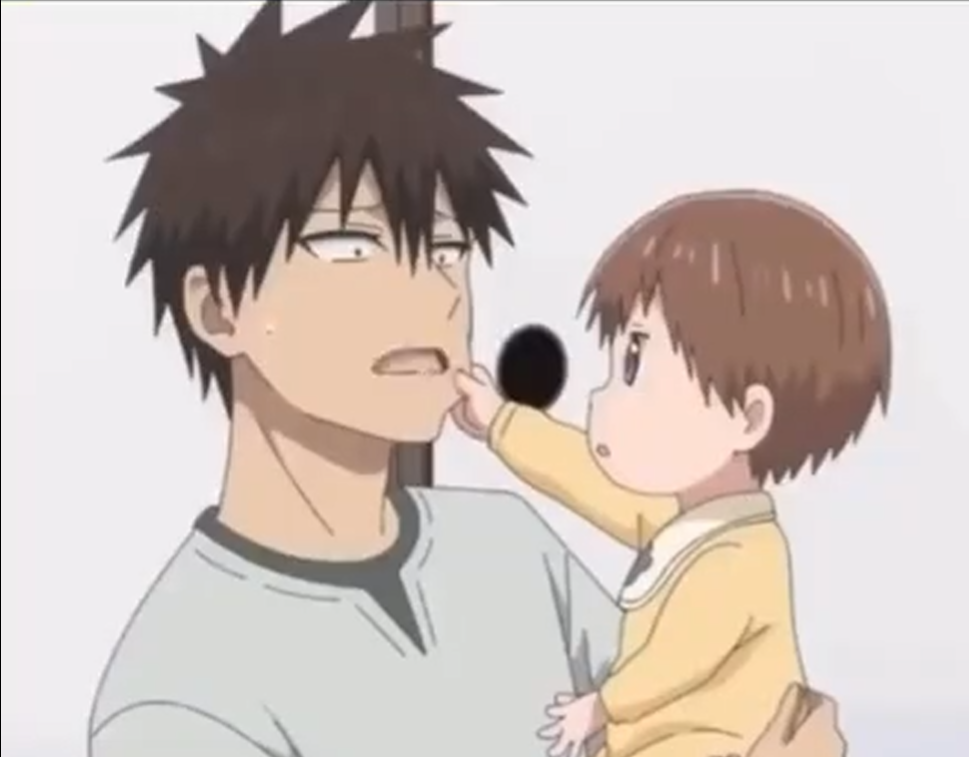

In [3]:
from PIL import Image

# Use a raw string so Windows path separators are interpreted correctly.
pic = Image.open(r"image.png")

pic

In [4]:
type(pic)

PIL.PngImagePlugin.PngImageFile

In [5]:
import numpy as np

# Convert the PIL image into a NumPy array for direct inspection and manipulation.
pic_array = np.array(pic)
print(f"Shape of pic_array: {pic_array.shape}")
pic_array

Shape of pic_array: (757, 969, 4)


array([[[  0,   0,   0, 255],
        [155, 162, 154, 255],
        [155, 162, 154, 255],
        ...,
        [164, 164, 164, 255],
        [164, 164, 164, 255],
        [164, 164, 164, 255]],

       [[  0,   0,   0, 255],
        [214, 220, 209, 255],
        [214, 220, 209, 255],
        ...,
        [224, 224, 224, 255],
        [224, 224, 224, 255],
        [224, 224, 224, 255]],

       [[  0,   0,   0, 255],
        [237, 242, 229, 255],
        [237, 242, 229, 255],
        ...,
        [244, 244, 244, 255],
        [244, 244, 244, 255],
        [244, 244, 244, 255]],

       ...,

       [[  0,   0,   0, 255],
        [234, 231, 236, 255],
        [234, 231, 236, 255],
        ...,
        [224, 222, 234, 255],
        [224, 222, 234, 255],
        [224, 222, 234, 255]],

       [[  0,   0,   0, 255],
        [234, 231, 236, 255],
        [234, 231, 236, 255],
        ...,
        [224, 222, 234, 255],
        [224, 222, 234, 255],
        [224, 222, 234, 255]],

       [[  0

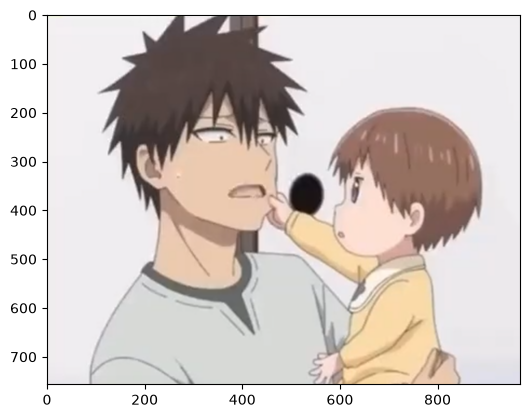

In [6]:
import matplotlib.pyplot as plt

# Plot the NumPy image array to confirm the image loaded correctly.
plt.imshow(pic_array)

### Exploring RGB Channels

In [7]:
# Create separate copies so each color channel can be isolated independently.
pic_red = pic_array.copy()
pic_green = pic_array.copy()
pic_blue = pic_array.copy()

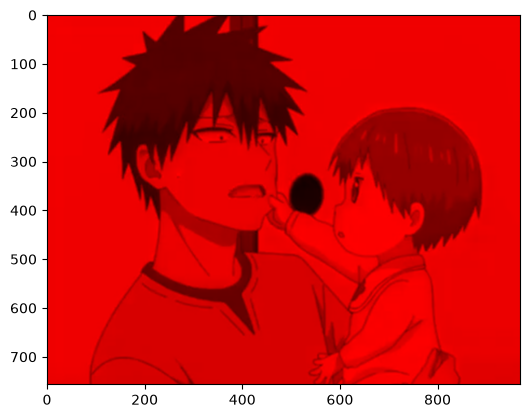

In [8]:
# Remove green and blue so only the red channel remains visible.
pic_red[:, :, 1] = 0
pic_red[:, :, 2] = 0
plt.imshow(pic_red)

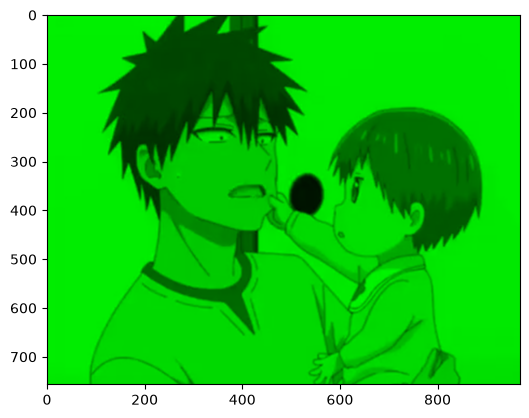

In [9]:
# Remove red and blue so only the green channel remains visible.
pic_green[:, :, 0] = 0
pic_green[:, :, 2] = 0
plt.imshow(pic_green)

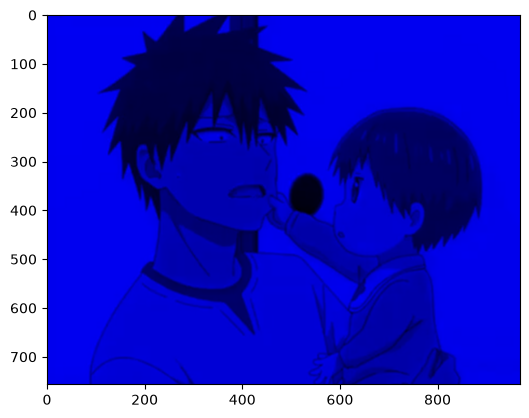

In [10]:
# Remove red and green so only the blue channel remains visible.
pic_blue[:, :, 0] = 0
pic_blue[:, :, 1] = 0
plt.imshow(pic_blue)

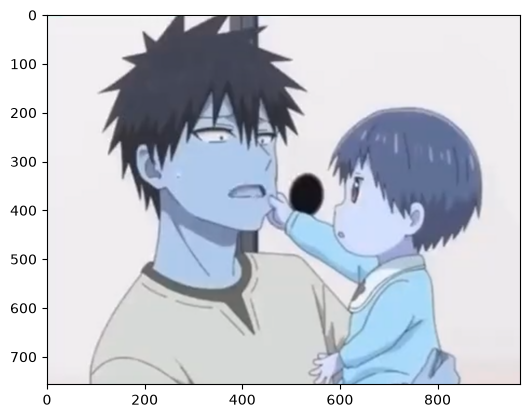

In [11]:
import cv2  # OpenCV reads images in BGR order by default.

img = cv2.imread("image.png")  # Load the raw OpenCV image.
plt.imshow(img)  # Display the unconverted image for comparison.

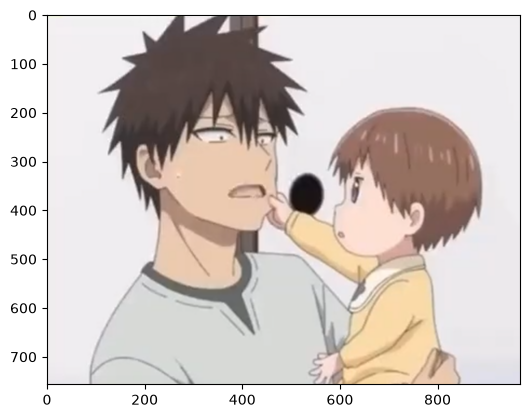

In [12]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB so colors display correctly in Matplotlib.
plt.imshow(img_rgb)

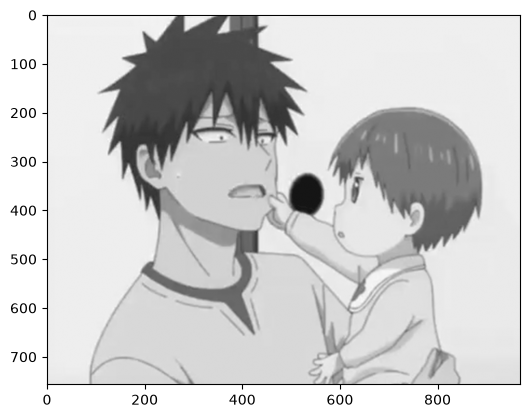

In [13]:
img_gray = cv2.imread("image.png", cv2.IMREAD_GRAYSCALE)  # Load intensity values only.
plt.imshow(img_gray, cmap='gray')  # Render the grayscale image with a gray colormap.

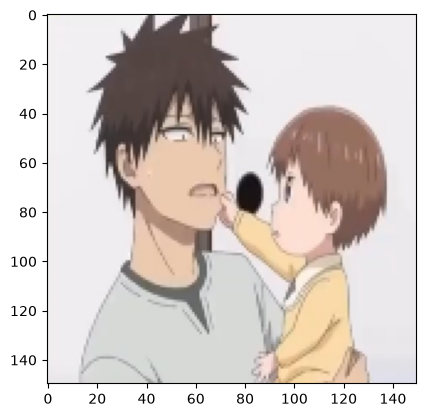

In [14]:
img_resized = cv2.resize(img_rgb, (150, 150))  # Resize to a fixed 150x150 shape for later processing.
plt.imshow(img_resized)

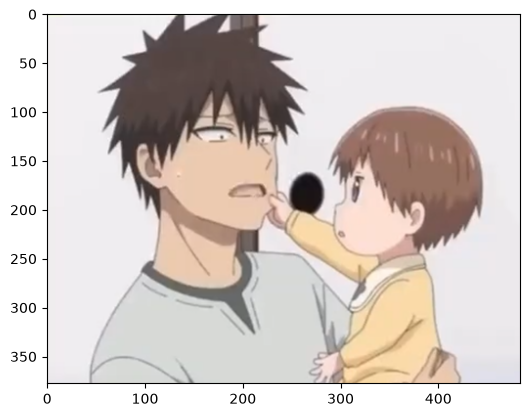

In [15]:
w_ratio = 0.5  # Scale the width by half.
h_ratio = 0.5  # Scale the height by half.

new_img_resized = cv2.resize(img_rgb, (0, 0), fx=w_ratio, fy=h_ratio)  # Resize proportionally using scale factors.
plt.imshow(new_img_resized)

### Generating Images with Diffusion Models

In [17]:
from diffusers import DDPMPipeline  # Pretrained DDPM pipeline for image generation.

ddpm = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32").to("cuda")  # Move the pipeline to CUDA for faster sampling.

ddpm

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]An error occurred while trying to fetch C:\Users\lovep\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\lovep\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00, 40.35it/s]


DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.38.0",
  "_name_or_path": "google/ddpm-cifar10-32",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

100%|██████████| 50/50 [00:01<00:00, 38.45it/s]


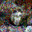

In [18]:
image = ddpm(num_inference_steps=50).images[0]  # Generate a sample image from the diffusion pipeline.

image

In [19]:
from diffusers import DDPMScheduler, UNet2DModel  # Components used for manual denoising.

scheduler = DDPMScheduler.from_pretrained("google/ddpm-celebahq-256")  # Load the scheduler configuration used during sampling.

scheduler

DDPMScheduler {
  "_class_name": "DDPMScheduler",
  "_diffusers_version": "0.38.0",
  "beta_end": 0.02,
  "beta_schedule": "linear",
  "beta_start": 0.0001,
  "clip_sample": true,
  "clip_sample_range": 1.0,
  "dynamic_thresholding_ratio": 0.995,
  "num_train_timesteps": 1000,
  "prediction_type": "epsilon",
  "rescale_betas_zero_snr": false,
  "sample_max_value": 1.0,
  "steps_offset": 0,
  "thresholding": false,
  "timestep_spacing": "leading",
  "trained_betas": null,
  "variance_type": "fixed_small"
}

In [20]:
model = UNet2DModel.from_pretrained("google/ddpm-celebahq-256").to("cuda")  # Load the pretrained UNet denoiser and place it on the GPU.

model

An error occurred while trying to fetch google/ddpm-celebahq-256: google/ddpm-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


UNet2DModel(
  (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0-1): 2 x DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Con

In [21]:
scheduler.set_timesteps(50)  # Configure the reverse diffusion process to use 50 denoising steps.

scheduler.timesteps

tensor([980, 960, 940, 920, 900, 880, 860, 840, 820, 800, 780, 760, 740, 720,
        700, 680, 660, 640, 620, 600, 580, 560, 540, 520, 500, 480, 460, 440,
        420, 400, 380, 360, 340, 320, 300, 280, 260, 240, 220, 200, 180, 160,
        140, 120, 100,  80,  60,  40,  20,   0])

In [22]:
import torch

sample_size = model.config.sample_size  # Read the native sample size expected by the UNet.

sample_size

256

In [23]:
noise = torch.randn((1, 3, sample_size, sample_size), device="cuda")  # Start the reverse diffusion process from Gaussian noise.
noise

tensor([[[[ 0.6706,  0.8908,  0.9895,  ...,  0.2567, -1.7659,  0.4242],
          [-1.6212,  0.1752, -0.6467,  ..., -0.3161, -0.6846, -0.2443],
          [ 0.7336, -0.8592, -0.3016,  ..., -1.1575,  1.5288, -0.2550],
          ...,
          [ 0.3461,  0.0265, -1.6246,  ...,  0.3601, -0.8977,  0.9693],
          [ 1.6393, -2.1739,  0.9886,  ..., -0.2654, -1.2715, -1.0550],
          [-1.8715, -1.1857,  0.0253,  ...,  1.8061, -0.9340,  1.4707]],

         [[-0.8685,  0.3297,  0.2163,  ..., -1.7521, -0.4592,  1.2022],
          [ 1.3805, -0.5139, -0.3934,  ...,  0.9235,  0.2727, -1.6866],
          [-0.3733, -0.9748, -0.9238,  ..., -1.0916,  0.2756,  0.0232],
          ...,
          [-0.3002,  0.5315,  1.1319,  ...,  0.5050, -1.4561, -0.9662],
          [-0.4720, -1.1559,  1.0746,  ...,  0.2711, -0.6323, -0.2102],
          [ 1.0057, -1.4440, -0.4670,  ...,  0.0336,  0.3525, -0.2486]],

         [[-0.2364,  0.6989,  0.3358,  ..., -0.5913, -0.2671, -0.2397],
          [ 0.2364,  0.5965,  

In [24]:
input = noise

for t in scheduler.timesteps:
    with torch.inference_mode():  # Reduce overhead while sampling.
        noise_residual = model(input, t).sample  # Predict the noise component at the current timestep.

        previous_noisy_sample = scheduler.step(noise_residual, t, input).prev_sample  # Step one timestep backward in the diffusion chain.
        
        input = previous_noisy_sample  # Feed the denoised sample into the next iteration.

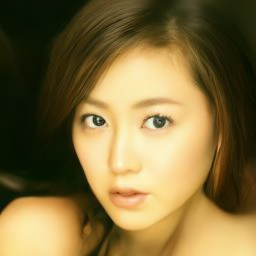

In [25]:
from PIL import Image

image = (input / 2 + 0.5).clamp(0, 1).squeeze()

image = (image.permute(1,2,0) * 255).round().to(torch.uint8).cpu().numpy()  # Convert the tensor to a NumPy array for display.

image = Image.fromarray(image)  # Convert the NumPy array to a PIL Image for display.

image

### Generating Images using a prompt with Diffusion

In [ ]:
import torch
from diffusers import DiffusionPipeline

image_generator = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", dtype=torch.bfloat16, device_map="cuda")

prompt = "Astronaut in a jungle, cold color palette, muted colors, detailed, 8k"
image = image_generator(prompt).images[0]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Fetching 19 files:  11%|█         | 2/19 [00:00<00:03,  4.49it/s]Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install